# Part B: Deep Learning - Neural Network for Insurance Claim Prediction

In [13]:
import google.protobuf

print(google.protobuf.__version__)

print(google.protobuf.__file__)

5.29.6
c:\Users\261606\Desktop\GenAI\genaienv\Lib\site-packages\google\protobuf\__init__.py


In [14]:
import sys

print(sys.executable)

print(sys.version)

c:\Users\261606\Desktop\GenAI\genaienv\Scripts\python.exe
3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


In [15]:
import tensorflow as tf
print(tf.__version__)


2.18.0


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('Libraries imported!')

TensorFlow version: 2.18.0
Libraries imported!


# DATA PREPROCESSING (Same as Part A)

In [17]:
df = pd.read_csv('../insurance2.csv')
print(f'Dataset shape: {df.shape}')
print(df.head())

Dataset shape: (1338, 8)
   age  sex     bmi  children  smoker  region      charges  insuranceclaim
0   19    0  27.900         0       1       3  16884.92400               1
1   18    1  33.770         1       0       2   1725.55230               1
2   28    1  33.000         3       0       2   4449.46200               0
3   33    1  22.705         0       0       1  21984.47061               0
4   32    1  28.880         0       0       1   3866.85520               1


In [18]:
X = df.drop('insuranceclaim', axis=1)
y = df['insuranceclaim']
X_processed = X.copy()
categorical_cols = X_processed.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col])
    label_encoders[col] = le
print('Categorical variables encoded')

Categorical variables encoded


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 936, Test: 402


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Scaling complete')

Scaling complete


# TASK 7: DESIGN A NEURAL NETWORK

**Architecture:**
- Input: 7 features
- Hidden 1: 32 neurons (ReLU)
- Hidden 2: 16 neurons (ReLU)
- Dropout: 0.2
- Output: 1 neuron (Sigmoid)
- Optimizer: Adam
- Epochs: 100

In [21]:
model = Sequential([
    layers.Input(shape=(7,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Neural Network Architecture:')
model.summary()

Neural Network Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

## Why This Architecture?

1. **Two Hidden Layers**: Learn non-linear relationships
2. **32 -> 16 neurons**: Bottleneck design for better generalization
3. **ReLU activation**: Non-linear, computationally efficient
4. **Dropout 0.2**: Prevent overfitting
5. **Sigmoid output**: Binary classification probability
6. **Adam optimizer**: Adaptive learning rate
7. **Binary crossentropy**: Standard binary classification loss

# TASK 8: TRAIN THE MODEL

In [22]:
print('Training neural network...')
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print('Training completed!')

Training neural network...
Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6176 - loss: 0.6695 - val_accuracy: 0.6330 - val_loss: 0.6317
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6751 - loss: 0.6078 - val_accuracy: 0.6915 - val_loss: 0.5764
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7259 - loss: 0.5572 - val_accuracy: 0.7660 - val_loss: 0.5264
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8061 - loss: 0.5013 - val_accuracy: 0.7819 - val_loss: 0.4819
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8302 - loss: 0.4532 - val_accuracy: 0.8138 - val_loss: 0.4469
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8489 - loss: 0.4152 - val_accuracy: 0.8191 - val_loss: 0.4196
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8570 - loss: 0.3883 - val_accuracy: 0.8511 - val_loss: 0.3969
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8663 - loss: 0.372

# TASK 9: OVERFITTING AND MODEL IMPROVEMENT

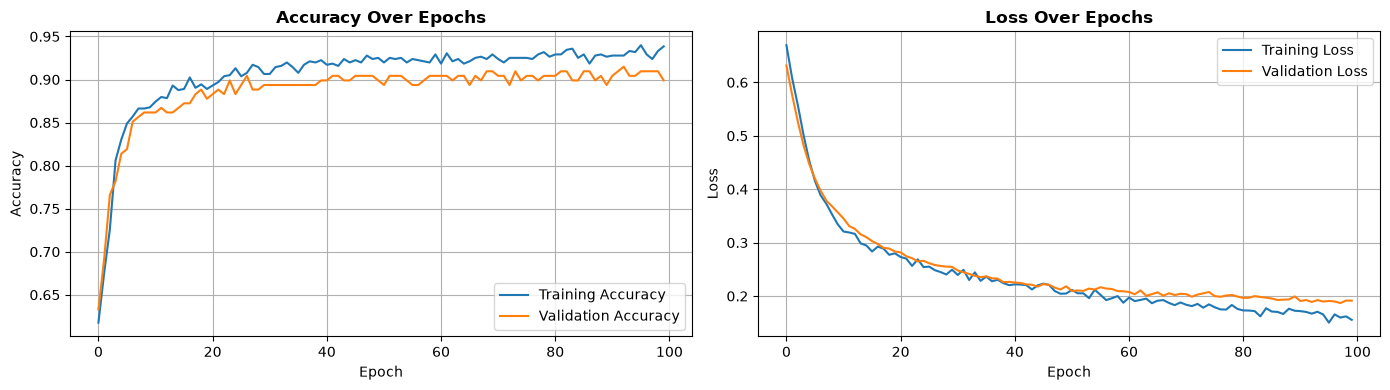

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy Over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss Over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [24]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print('='*60)
print('TRAINING ANALYSIS')
print('='*60)
print(f'Final Training Accuracy: {final_train_acc:.4f}')
print(f'Final Validation Accuracy: {final_val_acc:.4f}')
print(f'Accuracy Difference: {final_train_acc - final_val_acc:.4f}')
print(f'\nFinal Training Loss: {final_train_loss:.4f}')
print(f'Final Validation Loss: {final_val_loss:.4f}')

if final_train_acc < 0.7 and final_val_acc < 0.7:
    status = 'UNDERFITTING'
elif abs(final_train_acc - final_val_acc) > 0.1:
    status = 'OVERFITTING'
else:
    status = 'PROPERLY FITTED'

print(f'\nModel Status: {status}')

TRAINING ANALYSIS
Final Training Accuracy: 0.9385
Final Validation Accuracy: 0.8989
Accuracy Difference: 0.0396

Final Training Loss: 0.1555
Final Validation Loss: 0.1913

Model Status: PROPERLY FITTED


## Question: If training accuracy increases while validation accuracy declines?

**Answer: OVERFITTING**

This means:
- Model is memorizing training data noise
- Not generalizing to new data
- Solutions: Dropout, regularization, early stopping, more data

# TASK 10: EVALUATE THE MODEL

In [25]:
y_pred_proba_nn = model.predict(X_test_scaled)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int).flatten()
nn_accuracy = accuracy_score(y_test, y_pred_nn)

print('='*60)
print('NEURAL NETWORK EVALUATION')
print('='*60)
print(f'Test Accuracy: {nn_accuracy:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_nn))
print(f'\nConfusion Matrix:')
cm_nn = confusion_matrix(y_test, y_pred_nn)
print(cm_nn)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
NEURAL NETWORK EVALUATION
Test Accuracy: 0.8930

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       167
           1       0.94      0.88      0.91       235

    accuracy                           0.89       402
   macro avg       0.89      0.90      0.89       402
weighted avg       0.90      0.89      0.89       402


Confusion Matrix:
[[153  14]
 [ 29 206]]


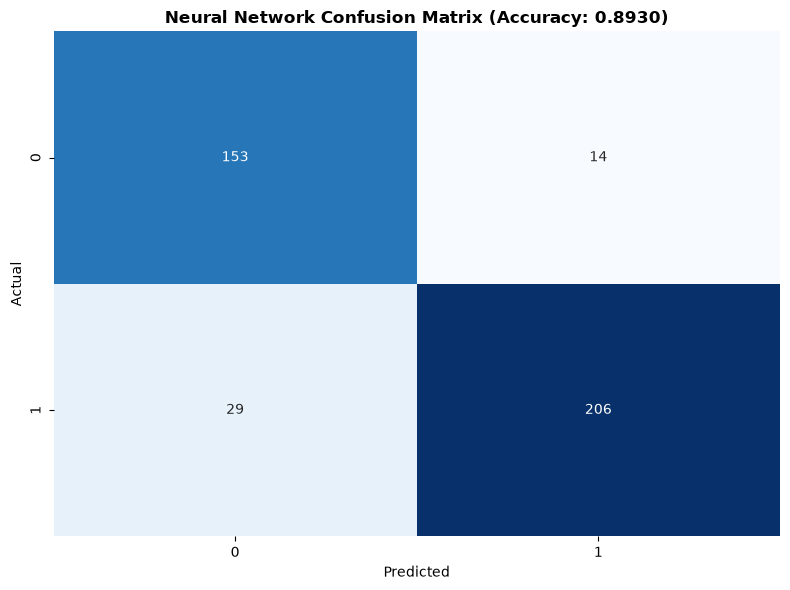

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=False)
ax.set_title(f'Neural Network Confusion Matrix (Accuracy: {nn_accuracy:.4f})', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# SUMMARY

## Part B - Deep Learning

✓ Task 7: Designed NN with 2 hidden layers, ReLU, dropout
✓ Task 8: Trained for 100 epochs with Adam optimizer
✓ Task 9: Analyzed training curves for fit status
✓ Task 10: Evaluated on test set

**Architecture:** 7 -> 32 -> 16 -> 1 neurons
**Test Accuracy:** (Run to see results)
**Next:** Part C - LangChain + RAG